In [205]:
"""
Constructs the DFT of the dihedral group in SageMath using knowledge of the representation theory.

""";

In [206]:
# ── Configuration ──────────────────────────────────────────────────────────────
n = 5; print("n =", n)
USE_FINITE_FIELD = True
p = 23; print("p =", p) # characteristic of the finite field
q = 23; print("q =", q) # size of the finite field

n = 5
p = 23
q = 23


In [207]:
# ── Build the coefficient ring and choose omega ─────────────────────────────────
if USE_FINITE_FIELD:
    # Find the smallest k such that n | (q^k - 1),
    # i.e. the multiplicative order of q mod n.
    k = Zmod(n)(q).multiplicative_order()
    F = GF(q**k, 'a')
    print(f"Working in GF({q}^{k}) = GF({q**k})")

    # Find a primitive n-th root of unity in F.
    # The multiplicative group of GF(q^k) is cyclic of order q^k - 1,
    # so a generator g satisfies g^((q^k-1)/n) has order n.
    g = F.multiplicative_generator()
    omega = g**((q**k - 1) // n)
    assert omega**n == F.one(), "omega is not an n-th root of unity"
    assert omega**(n-1) != F.one() or n == 1, "omega is not primitive"
    print(f"omega = {omega}  (order {omega.multiplicative_order()})")
else:
    K.<z> = CyclotomicField(n) #cyclotomic field containing a primitive n-th root of unity
    omega = z; print(f"omega = {omega}  (primitive n-th root of unity)")

Working in GF(23^4) = GF(279841)
omega = a^3 + 2*a^2 + 16*a + 17  (order 5)


In [208]:
G = DihedralGroup(n); print("G =", G) #D_n, dihedral group of order 2n
r = [g for g in G if g.order() == n][0] #rotation of order n, generator
s = [g for g in G if g.order() == 2 and g != r**(n//2)][0] #flip of order 2, generator
print("r =", r)
print("s =", s)

G = Dihedral group of order 10 as a permutation group
r = (1,5,4,3,2)
s = (2,5)(3,4)


In [209]:
# returns (0, k) if g = r^k and (1, k) if g = s*r^k
def express_in_gens(g):
    for k in range(n):
        if g == r**k:
            return (0, k)
    for k in range(n):
        if g == s * r**k:
            return (1, k)

In [210]:
# n odd, we have two 1-dim'l irreps and (n-1)/2 2-dim'l irreps
# the 1-dim's irreps are trivial and sign
# the 2-dim'l irreps are given by rotation matrices and a flip matrix
def rho_odd(k, g, omega):
    (s_exp, r_exp) = express_in_gens(g)
    if k == 0:
        return matrix([1])
    if k == -1:
        if s_exp == 0:
            return matrix([1])
        if s_exp == 1:
            return matrix([-1])
    if k >= 1:
        if s_exp == 0:
            return matrix([[omega**(k*r_exp), 0], [0, omega**(-k*r_exp)]])
        if s_exp == 1:
            return matrix([[0, omega**(k*r_exp)], [omega**(-k*r_exp), 0]])

In [211]:
def dft_matrix_odd(omega):
    assert n % 2 == 1
    rows = []
    for g in G:
        row = [rho_odd(k, g, omega).list() for k in range(-1,(n-1)//2 + 1)]
        rows.append(sum(row, []))
    return matrix(rows)

In [212]:
# for n even case
def rho_even(k, g, omega):
    (s_exp, r_exp) = express_in_gens(g)
    if k == 0:   # trivial
        return matrix([1])
    if k == -1:  # sign of rotation
        return matrix([(-1)**r_exp])
    if k == -2:  # sign of reflection
        return matrix([(-1)**s_exp])
    if k == -3:  # total sign
        return matrix([(-1)**(r_exp + s_exp)])
    if k >= 1:
        if s_exp == 0:
            return matrix([[omega**(k*r_exp), 0], [0, omega**(-k*r_exp)]])
        if s_exp == 1:
            return matrix([[0, omega**(k*r_exp)], [omega**(-k*r_exp), 0]])

In [213]:
# form the DFT matrix for n even
def dft_matrix_even(omega):
    assert n % 2 == 0
    rows = []
    for g in G:
        row = [rho_even(k, g, omega).list() for k in range(-3, n//2)]
        rows.append(sum(row, []))
    return matrix(rows)

In [214]:
DFT_matrix = dft_matrix_odd(omega) if n % 2 == 1 else dft_matrix_even(omega); print(DFT_matrix)

[                        1                         1                         1                         0                         0                         1                         1                         0                         0                         1]
[                        1                         1   a^3 + 2*a^2 + 16*a + 17                         0                         0  12*a^3 + a^2 + 10*a + 17 21*a^3 + 6*a^2 + 12*a + 9                         0                         0 12*a^3 + 14*a^2 + 8*a + 2]
[                        1                         1 21*a^3 + 6*a^2 + 12*a + 9                         0                         0 12*a^3 + 14*a^2 + 8*a + 2  12*a^3 + a^2 + 10*a + 17                         0                         0   a^3 + 2*a^2 + 16*a + 17]
[                        1                         1 12*a^3 + 14*a^2 + 8*a + 2                         0                         0 21*a^3 + 6*a^2 + 12*a + 9   a^3 + 2*a^2 + 16*a + 17                         0      

In [215]:
f = DFT_matrix.charpoly(); print(f)

x^10 + (a^3 + 15*a^2 + 14*a + 1)*x^9 + (18*a^3 + 3*a^2 + a + 22)*x^8 + (a^3 + 3*a^2 + a + 1)*x^7 + (22*a^3 + 9*a^2 + 7*a + 21)*x^6 + (12*a^3 + 17*a^2 + 20*a + 5)*x^5 + (15*a^3 + 12*a^2 + 16*a + 22)*x^4 + (6*a^3 + 5*a^2 + 9*a + 10)*x^3 + (14*a^3 + 14*a^2 + 5*a + 14)*x^2 + (3*a^3 + 17*a^2 + 2*a + 3)*x + 17


In [216]:
if USE_FINITE_FIELD:
    L.<a> = f.splitting_field(); print(L)

Finite Field in a of size 23^56


In [217]:
if USE_FINITE_FIELD:
    R_L.<x> = PolynomialRing(L)
    f_L = R_L(f)
    f_L.factor()

In [218]:
if USE_FINITE_FIELD:
    eigenvalues = f.roots(L, multiplicities=False)
    print(eigenvalues)
    print(len(eigenvalues))

[16*a^55 + 4*a^54 + 8*a^53 + 6*a^52 + 18*a^51 + 8*a^50 + 3*a^49 + 16*a^48 + 15*a^47 + 15*a^46 + 19*a^45 + 5*a^44 + 22*a^43 + 11*a^42 + 17*a^41 + 6*a^40 + 10*a^39 + 13*a^38 + 14*a^37 + 4*a^36 + 6*a^35 + 20*a^34 + 19*a^33 + 16*a^32 + 2*a^31 + 7*a^30 + 12*a^29 + 15*a^28 + 14*a^27 + 10*a^26 + 22*a^25 + 13*a^23 + 18*a^22 + 19*a^21 + 20*a^19 + 7*a^18 + 21*a^17 + 11*a^16 + 20*a^15 + 3*a^14 + 13*a^13 + 21*a^12 + 22*a^11 + 4*a^10 + 12*a^9 + 4*a^8 + 3*a^7 + 19*a^6 + 2*a^5 + 20*a^4 + 13*a^3 + 14*a^2 + 11*a + 17, 4*a^55 + 4*a^53 + 21*a^52 + 2*a^51 + a^50 + 8*a^49 + 18*a^48 + 17*a^47 + 2*a^46 + 19*a^45 + 2*a^44 + 16*a^43 + a^42 + 12*a^41 + 7*a^40 + 6*a^39 + 19*a^38 + 12*a^36 + 13*a^35 + 18*a^34 + 5*a^33 + 17*a^32 + a^31 + 3*a^30 + 14*a^29 + 20*a^28 + 5*a^27 + 2*a^26 + 10*a^24 + 11*a^23 + a^22 + 11*a^21 + 16*a^20 + 15*a^19 + 15*a^18 + 18*a^17 + 2*a^16 + 3*a^15 + 21*a^13 + 21*a^12 + 14*a^11 + 17*a^10 + 3*a^9 + 19*a^8 + 18*a^7 + 8*a^6 + 14*a^5 + 3*a^4 + 10*a^3 + a^2 + 10*a + 17, 20*a^55 + 2*a^54 + 18*

In [219]:
def frobenius(x, p):
    return x**p

In [220]:
def frobenius_orbit(alpha, p):
    orbit = []
    seen = set()
    
    x = alpha
    while x not in seen:
        seen.add(x)
        orbit.append(x)
        x = x^p
    
    return orbit

In [221]:
def frobenius_orbits(eigenvalues, p):
    orbits = []
    seen = set()
    
    for lam in eigenvalues:
        if lam not in seen:
            orb = frobenius_orbit(lam, p)
            orbits.append(orb)
            seen.update(orb)
    
    return orbits

In [222]:
def discrete_log_Fq(x, alpha=None):
    F = x.parent()
    if x == 0:
        raise ValueError("Log undefined for 0")
    if alpha is None:
        alpha = F.multiplicative_generator()
    return x.log(alpha)

In [223]:
frobenius_orbits(eigenvalues, p)

[[16*a^55 + 4*a^54 + 8*a^53 + 6*a^52 + 18*a^51 + 8*a^50 + 3*a^49 + 16*a^48 + 15*a^47 + 15*a^46 + 19*a^45 + 5*a^44 + 22*a^43 + 11*a^42 + 17*a^41 + 6*a^40 + 10*a^39 + 13*a^38 + 14*a^37 + 4*a^36 + 6*a^35 + 20*a^34 + 19*a^33 + 16*a^32 + 2*a^31 + 7*a^30 + 12*a^29 + 15*a^28 + 14*a^27 + 10*a^26 + 22*a^25 + 13*a^23 + 18*a^22 + 19*a^21 + 20*a^19 + 7*a^18 + 21*a^17 + 11*a^16 + 20*a^15 + 3*a^14 + 13*a^13 + 21*a^12 + 22*a^11 + 4*a^10 + 12*a^9 + 4*a^8 + 3*a^7 + 19*a^6 + 2*a^5 + 20*a^4 + 13*a^3 + 14*a^2 + 11*a + 17,
  3*a^55 + 9*a^54 + 15*a^53 + 11*a^52 + 10*a^51 + 8*a^50 + 12*a^49 + 7*a^48 + 2*a^47 + 20*a^46 + 11*a^45 + 12*a^43 + 15*a^42 + 21*a^41 + 10*a^40 + 9*a^39 + 13*a^38 + 15*a^37 + 15*a^36 + 20*a^35 + 12*a^34 + 7*a^33 + 12*a^32 + 7*a^31 + 18*a^30 + 18*a^29 + 12*a^28 + 12*a^27 + 9*a^26 + 5*a^25 + 8*a^24 + 6*a^23 + 17*a^22 + a^21 + 21*a^20 + 2*a^19 + 7*a^18 + 13*a^17 + 16*a^16 + 2*a^15 + 19*a^14 + 10*a^13 + a^12 + 19*a^11 + 14*a^10 + 21*a^9 + 3*a^8 + 16*a^7 + 17*a^6 + 6*a^5 + 15*a^4 + 8*a^3 + 9

In [ ]:
len(frobenius_orbit(eigenvalues[0], p))

[16*a^55 + 4*a^54 + 8*a^53 + 6*a^52 + 18*a^51 + 8*a^50 + 3*a^49 + 16*a^48 + 15*a^47 + 15*a^46 + 19*a^45 + 5*a^44 + 22*a^43 + 11*a^42 + 17*a^41 + 6*a^40 + 10*a^39 + 13*a^38 + 14*a^37 + 4*a^36 + 6*a^35 + 20*a^34 + 19*a^33 + 16*a^32 + 2*a^31 + 7*a^30 + 12*a^29 + 15*a^28 + 14*a^27 + 10*a^26 + 22*a^25 + 13*a^23 + 18*a^22 + 19*a^21 + 20*a^19 + 7*a^18 + 21*a^17 + 11*a^16 + 20*a^15 + 3*a^14 + 13*a^13 + 21*a^12 + 22*a^11 + 4*a^10 + 12*a^9 + 4*a^8 + 3*a^7 + 19*a^6 + 2*a^5 + 20*a^4 + 13*a^3 + 14*a^2 + 11*a + 17,
 3*a^55 + 9*a^54 + 15*a^53 + 11*a^52 + 10*a^51 + 8*a^50 + 12*a^49 + 7*a^48 + 2*a^47 + 20*a^46 + 11*a^45 + 12*a^43 + 15*a^42 + 21*a^41 + 10*a^40 + 9*a^39 + 13*a^38 + 15*a^37 + 15*a^36 + 20*a^35 + 12*a^34 + 7*a^33 + 12*a^32 + 7*a^31 + 18*a^30 + 18*a^29 + 12*a^28 + 12*a^27 + 9*a^26 + 5*a^25 + 8*a^24 + 6*a^23 + 17*a^22 + a^21 + 21*a^20 + 2*a^19 + 7*a^18 + 13*a^17 + 16*a^16 + 2*a^15 + 19*a^14 + 10*a^13 + a^12 + 19*a^11 + 14*a^10 + 21*a^9 + 3*a^8 + 16*a^7 + 17*a^6 + 6*a^5 + 15*a^4 + 8*a^3 + 9*a

In [225]:
dlogs = [discrete_log_Fq(x, alpha=None) for x in eigenvalues]; dlogs

[7563325988960297926591828144712042399504047485595319116525762803812602578920,
 3832966273629475783319223925935045600986299330461213886633214227642096149800,
 7876631860699190313139744935753736643781181145009768397448164999473703878598,
 12617529860924227136162153407776249857463273099192652232257783101527519166641,
 17999502490652238765046676273408333344996778744854139569716504101710894271720,
 814058264866177427497395256687477182539309230920082699067597568969757874321,
 11447624823506349648965266684094517901017861040720643350745061789561243632360,
 8523349106963218417903001851526378429755359848039002025333093094448934684840,
 3578838501683023465264403378323708283388120636596166853598389708298641436840,
 2097938488798333240234896792152810348597941003798255273914489141747529293800]

In [226]:
def brauer_map(x):
    if x == 0:
        return 0
    else:
        l = discrete_log_Fq(x, alpha=None)
        return exp(2 * pi * I * l / (L.order()-1))

In [227]:
complex_eigs = [brauer_map(eig) for eig in eigenvalues]; complex_eigs
eigs_num = [complex(e.n(digits=30)) for e in complex_eigs]; eigs_num

[(-0.8724935868352738+0.48862556311691124j),
 (0.23518591164077873+0.9719504035524116j),
 (-0.9204668327658685+0.3908206874999976j),
 (-0.3174960022662669-0.9482596103098236j),
 (0.9997658722233501-0.021637946702122116j),
 (0.9601692254105206+0.2794191449678436j),
 (-0.6669190940733992-0.74513013760035j),
 (-0.984455947891433+0.17563167897956297j),
 (0.3200801604319324+0.9473904637993082j),
 (0.7452966213057762+0.6667330397319412j)]

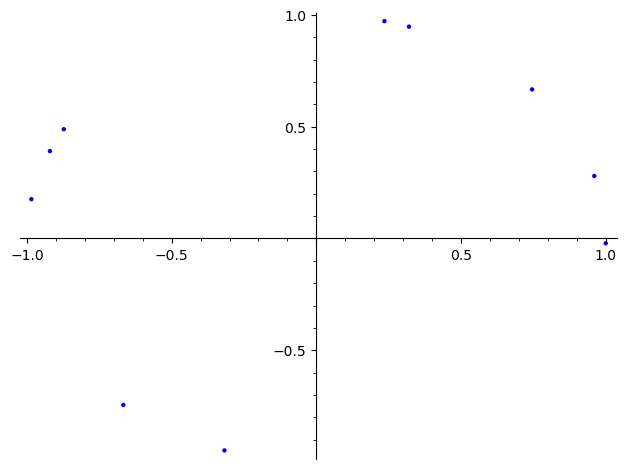

In [228]:
P = list_plot(
    [(z.real, z.imag) for z in eigs_num],
    plotjoined=False,
    marker='o'
)

P.show()

In [229]:
# can normalize by 1/sqrt(D) to get a unitary matrix
if not USE_FINITE_FIELD:
    print(DFT_matrix.conjugate_transpose() * DFT_matrix)

In [230]:
# form norm polynomial by acting on coefficients of characteristic polynomial by the Galois group
def norm_poly(f, n):

    def sigma(i):
        phi = K.hom([z**i])
        return f.map_coefficients(phi)
    
    units = [i for i in range(1, n) if gcd(i, n) == 1]  # (Z/nZ)^×
    result = prod(sigma(i) for i in units)
    return result.change_ring(QQ)

In [231]:
f = DFT_matrix.charpoly(); f

x^10 + (a^3 + 15*a^2 + 14*a + 1)*x^9 + (18*a^3 + 3*a^2 + a + 22)*x^8 + (a^3 + 3*a^2 + a + 1)*x^7 + (22*a^3 + 9*a^2 + 7*a + 21)*x^6 + (12*a^3 + 17*a^2 + 20*a + 5)*x^5 + (15*a^3 + 12*a^2 + 16*a + 22)*x^4 + (6*a^3 + 5*a^2 + 9*a + 10)*x^3 + (14*a^3 + 14*a^2 + 5*a + 14)*x^2 + (3*a^3 + 17*a^2 + 2*a + 3)*x + 17

In [232]:
if not USE_FINITE_FIELD:
    Nf = norm_poly(f, n); Nf

In [233]:
if not USE_FINITE_FIELD:
    Nf.is_irreducible()

In [234]:
if not USE_FINITE_FIELD:
    Nf.factor()

In [235]:
if not USE_FINITE_FIELD:
    Nf.galois_group()

In [236]:
if not USE_FINITE_FIELD:
    G = TransitiveGroup(12, 299)
    print(G.order())
    print(G.is_solvable())
    print(G.is_primitive())
    print(G.structure_description())